In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from IPython.display import display
from side_lib import *
from visual import *
from sklearn.pipeline import Pipeline
import phik

pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
data = pd.read_csv('df_train.csv')

In [3]:
data.head(5)

,date,price,bedrooms,grade,has_basement,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,has_lavatory,single_floor,month,quartile_zone
0,2014-05-15,"312,000.00",2,2,True,138.43,False,False,False,2,True,False,5,1
1,2014-11-14,"310,000.00",2,2,False,105.91,False,False,False,1,True,False,11,3
2,2014-12-24,"320,000.00",2,2,False,117.99,False,True,False,1,False,True,12,2
3,2015-02-22,"264,500.00",2,3,False,151.43,False,False,False,2,True,True,2,1
4,2015-01-06,"700,000.00",3,2,True,341.88,False,False,False,3,False,False,1,4


In [4]:
mis_dup_info(data)

,total,missing,percent_missing,duplicated,percent_duplicated
date,13603,0,0.0%,2,0.0%
price,13603,0,0.0%,2,0.0%
bedrooms,13603,0,0.0%,2,0.0%
grade,13603,0,0.0%,2,0.0%
has_basement,13603,0,0.0%,2,0.0%
living_in_m2,13603,0,0.0%,2,0.0%
renovated,13603,0,0.0%,2,0.0%
nice_view,13603,0,0.0%,2,0.0%
perfect_condition,13603,0,0.0%,2,0.0%
real_bathrooms,13603,0,0.0%,2,0.0%


In [5]:
data.drop_duplicates(inplace=True)

In [6]:
data_info(data)

'Первые строки'

,date,price,bedrooms,grade,has_basement,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,has_lavatory,single_floor,month,quartile_zone
0,2014-05-15,"312,000.00",2,2,True,138.43,False,False,False,2,True,False,5,1
1,2014-11-14,"310,000.00",2,2,False,105.91,False,False,False,1,True,False,11,3
2,2014-12-24,"320,000.00",2,2,False,117.99,False,True,False,1,False,True,12,2
3,2015-02-22,"264,500.00",2,3,False,151.43,False,False,False,2,True,True,2,1
4,2015-01-06,"700,000.00",3,2,True,341.88,False,False,False,3,False,False,1,4


'Описание данных'

,price,bedrooms,grade,living_in_m2,real_bathrooms,month,quartile_zone
count,"13,601.00","13,601.00","13,601.00","13,601.00","13,601.00","13,601.00","13,601.00"
mean,"475,287.24",2.24,2.53,181.73,1.68,6.58,2.43
std,"207,337.79",0.68,0.97,67.91,0.63,3.13,1.07
min,"81,000.00",1.00,1.00,49.24,1.00,1.00,1.00
25%,"315,000.00",2.00,2.00,130.06,1.00,4.00,2.00
50%,"435,000.00",2.00,2.00,171.87,2.00,6.00,2.00
75%,"599,950.00",3.00,3.00,224.83,2.00,9.00,3.00
max,"1,155,000.00",3.00,5.00,391.12,3.00,12.00,4.00


'Базовая системная информация'

<class 'pandas.core.frame.DataFrame'>
Index: 13601 entries, 0 to 13602
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               13601 non-null  object 
 1   price              13601 non-null  float64
 2   bedrooms           13601 non-null  int64  
 3   grade              13601 non-null  int64  
 4   has_basement       13601 non-null  bool   
 5   living_in_m2       13601 non-null  float64
 6   renovated          13601 non-null  bool   
 7   nice_view          13601 non-null  bool   
 8   perfect_condition  13601 non-null  bool   
 9   real_bathrooms     13601 non-null  int64  
 10  has_lavatory       13601 non-null  bool   
 11  single_floor       13601 non-null  bool   
 12  month              13601 non-null  int64  
 13  quartile_zone      13601 non-null  int64  
dtypes: bool(6), float64(2), int64(5), object(1)
memory usage: 1.0+ MB


None

count      13,601.00
mean      475,287.24
std       207,337.79
min        81,000.00
25%       315,000.00
50%       435,000.00
75%       599,950.00
max     1,155,000.00
Name: price, dtype: float64


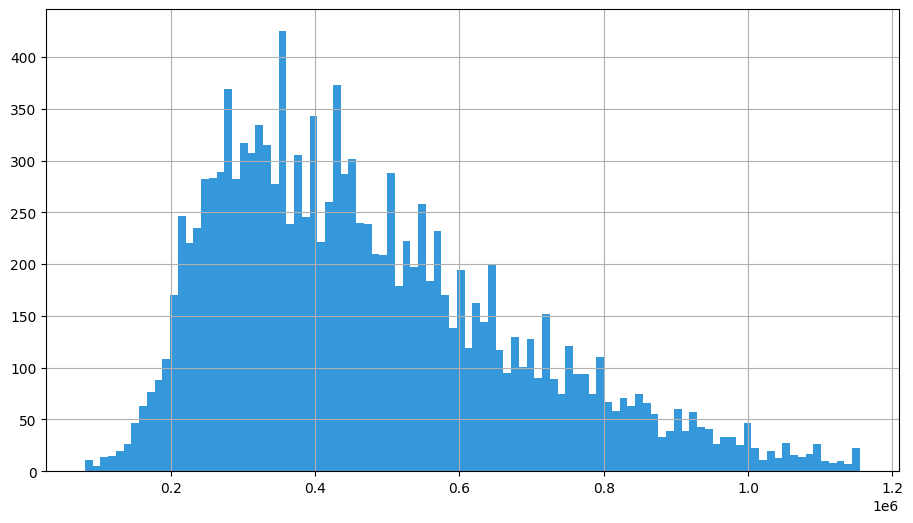

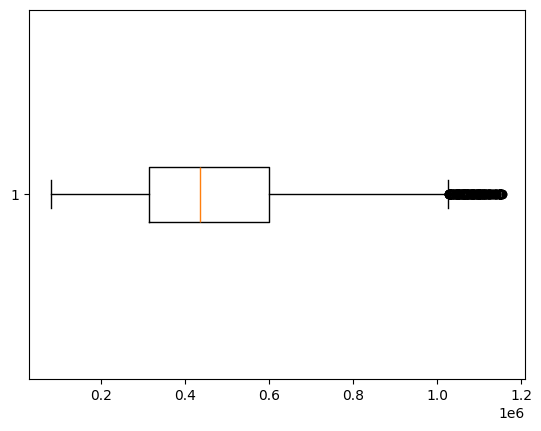

<Figure size 1500x600 with 0 Axes>

In [7]:
kol_info(data['price'],'','','')

In [8]:
data[data['price'] >= 1000000].describe()

,price,bedrooms,grade,living_in_m2,real_bathrooms,month,quartile_zone
count,242.00,242.00,242.00,242.00,242.00,242.00,242.00
mean,"1,068,441.03",2.67,3.98,285.03,2.31,6.61,3.57
std,"46,161.26",0.51,0.91,60.58,0.64,3.06,0.70
min,"1,000,000.00",1.00,1.00,133.78,1.00,1.00,1.00
25%,"1,030,000.00",2.00,3.00,242.71,2.00,4.00,3.00
50%,"1,065,000.00",3.00,4.00,282.43,2.00,6.00,4.00
75%,"1,100,000.00",3.00,5.00,333.29,3.00,9.00,4.00
max,"1,155,000.00",3.00,5.00,391.12,3.00,12.00,4.00


In [9]:
data[data['price'] <= 1000000].describe()

,price,bedrooms,grade,living_in_m2,real_bathrooms,month,quartile_zone
count,"13,375.00","13,375.00","13,375.00","13,375.00","13,375.00","13,375.00","13,375.00"
mean,"465,182.73",2.23,2.51,179.93,1.67,6.58,2.41
std,"193,747.15",0.68,0.95,66.60,0.62,3.13,1.07
min,"81,000.00",1.00,1.00,49.24,1.00,1.00,1.00
25%,"314,000.00",2.00,2.00,130.06,1.00,4.00,2.00
50%,"430,760.00",2.00,2.00,170.01,2.00,6.00,2.00
75%,"587,000.00",3.00,3.00,222.04,2.00,9.00,3.00
max,"1,000,000.00",3.00,5.00,391.12,3.00,12.00,4.00


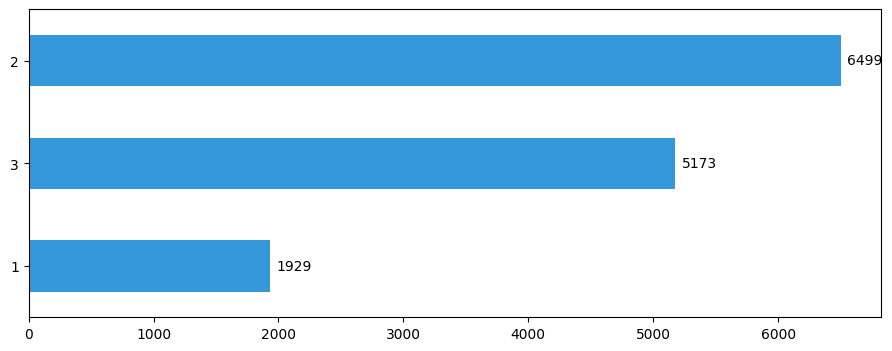

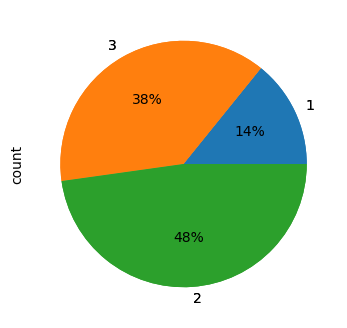

bedrooms
3   551,781.75
2   440,477.45
1   387,429.67
Name: price, dtype: float64

In [10]:
cat_info(data['bedrooms'],'','','')
data.groupby('bedrooms')['price'].mean().sort_values(ascending=False)

In [11]:
data['month'] = data['month'].astype('Int64')

In [12]:
data['month'].value_counts().sort_index

<bound method Series.sort_index of month
5     1504
4     1396
7     1371
6     1337
8     1210
3     1206
10    1180
9     1157
12     936
11     892
2      801
1      611
Name: count, dtype: Int64>

<Axes: xlabel='month'>

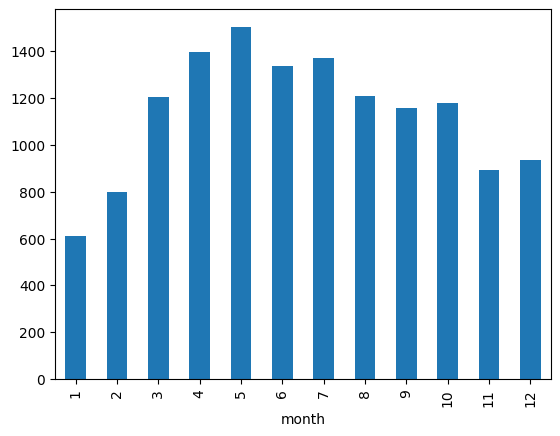

In [13]:
data['month'].value_counts().sort_index().plot(kind='bar')

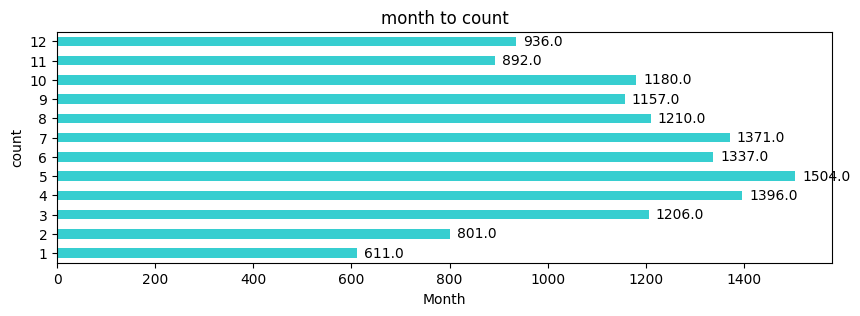

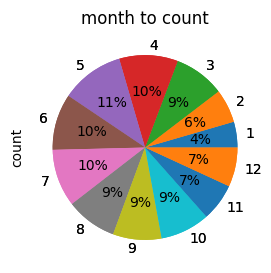

In [14]:
cat_info(data['month'], 'Month', 'count', 'month to count', index_sort=True, figsize=(10,3), color="#37CED0")

In [15]:
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')


<Axes: xlabel='date'>

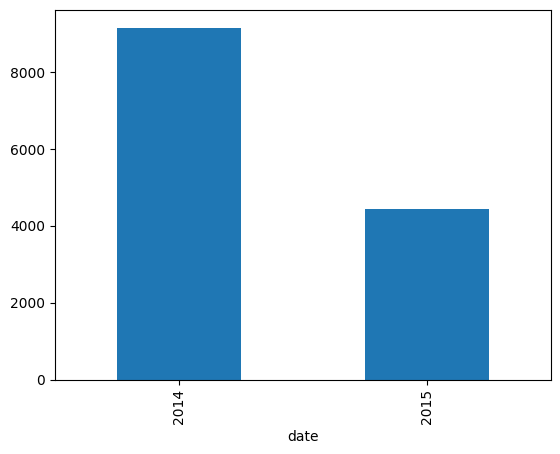

In [16]:
data['date'].dt.year.value_counts().sort_index().plot(kind='bar')

In [17]:
data['log_price'] = np.log(data['price'])

In [18]:

X = data.drop(columns=["log_price", "price"])
y = data["log_price"]
RANDOM_STATE = 42

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()
#categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
display("Numeric features:", numeric_features)

'Numeric features:'

['bedrooms',
 'grade',
 'has_basement',
 'living_in_m2',
 'renovated',
 'nice_view',
 'perfect_condition',
 'real_bathrooms',
 'has_lavatory',
 'single_floor',
 'month',
 'quartile_zone']

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13601 entries, 0 to 13602
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               13601 non-null  datetime64[ns]
 1   price              13601 non-null  float64       
 2   bedrooms           13601 non-null  int64         
 3   grade              13601 non-null  int64         
 4   has_basement       13601 non-null  bool          
 5   living_in_m2       13601 non-null  float64       
 6   renovated          13601 non-null  bool          
 7   nice_view          13601 non-null  bool          
 8   perfect_condition  13601 non-null  bool          
 9   real_bathrooms     13601 non-null  int64         
 10  has_lavatory       13601 non-null  bool          
 11  single_floor       13601 non-null  bool          
 12  month              13601 non-null  Int64         
 13  quartile_zone      13601 non-null  int64         
 14  log_price  

<Axes: ylabel='Frequency'>

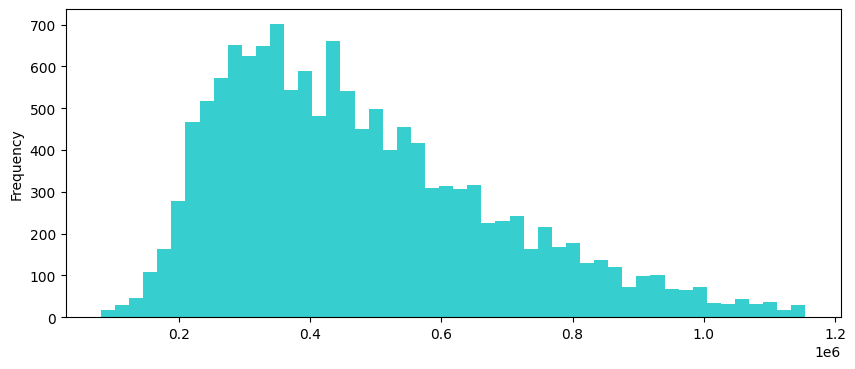

In [20]:
data['price'].plot(kind='hist', bins=50, figsize=(10,4), color="#37CED0")

In [21]:


pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe.fit(X_train[numeric_features], y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [22]:
y_pred = pipe.predict(X_test[numeric_features])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Baseline (Scaled Linear Regression) RMSE: {rmse:.2f}")
print("R2 LinearRegression =", r2)

print(y.describe())


Baseline (Scaled Linear Regression) RMSE: 0.22
R2 LinearRegression = 0.7451910084004774
count   13,601.00
mean        12.98
std          0.44
min         11.30
25%         12.66
50%         12.98
75%         13.30
max         13.96
Name: log_price, dtype: float64


In [23]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train[numeric_features], y_train)  # обычные цены

y_pred = lgb_model.predict(X_test[numeric_features])  # просто предсказание
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("R2 LightGBM =", r2)
print(f"RMSE LightGBM: {rmse:.2f}")



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000824 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 10200, number of used features: 12
[LightGBM] [Info] Start training from score 12.976405
R2 LightGBM = 0.7738011747332465
RMSE LightGBM: 0.21


In [24]:
print(y.describe())


count   13,601.00
mean        12.98
std          0.44
min         11.30
25%         12.66
50%         12.98
75%         13.30
max         13.96
Name: log_price, dtype: float64


In [25]:

scaler = StandardScaler()
encoder = OneHotEncoder(drop='first', sparse=False)

X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

model_lr  = LinearRegression()
model_lr.fit(X_train, y_train)
predictions = model_lr.predict(X_test)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print("R2 LinearRegression =", r2)
print("RMSE LinearRegression =", rmse)

NameError: name 'OneHotEncoder' is not defined

In [26]:
from sklearn.ensemble import RandomForestRegressor



rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],   # количество деревьев
    'max_depth': [None, 5, 10],       # максимальная глубина дерева
    'min_samples_split': [2, 5, 10],  # минимальное число объектов для разбиения узла
}


In [31]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train[numeric_features], y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшее CV RMSE:", (-grid_search.best_score_)**0.5)


Лучшие параметры: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Лучшее CV RMSE: 0.21312283400278167


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test[numeric_features])
rmse = mean_squared_error(y_test, y_pred)**0.5
print("Test RMSE:", rmse)

Test RMSE: 0.21272725351209487


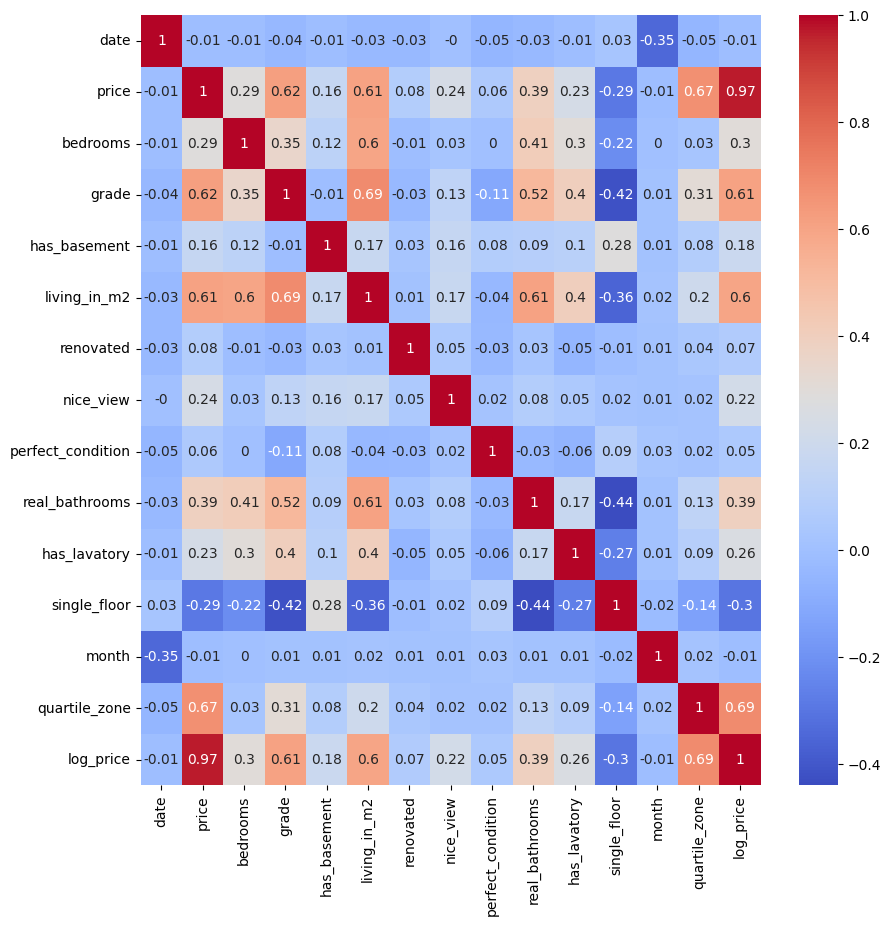

In [43]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr().round(2), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
phik_matrix = data.phik_matrix()

sns.heatmap(phik_matrix().round(2), annot=True, cmap='coolwarm')

interval columns not set, guessing: ['price', 'bedrooms', 'grade', 'living_in_m2', 'real_bathrooms', 'month', 'quartile_zone', 'log_price']


TypeError: 'DataFrame' object is not callable

interval columns not set, guessing: ['price', 'bedrooms', 'grade', 'living_in_m2', 'real_bathrooms', 'month', 'quartile_zone', 'log_price']


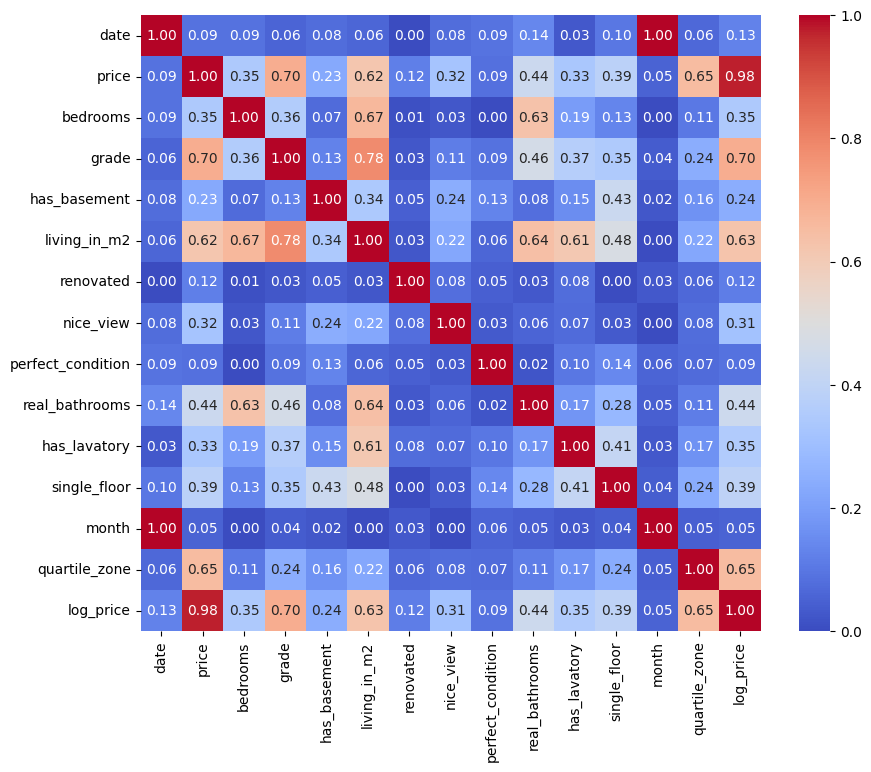

In [52]:
phik_matrix = data.phik_matrix()
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.show()